<a href="https://colab.research.google.com/github/danieligelnik/CCFraudProject/blob/main/DS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
%pip install kagglehub[pandas-datasets]

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def load_kagglehub_dataset(dataset_path, file_name):
  # Load the latest version
  return kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      dataset_path,
      file_name,
      # Provide any additional arguments like
      # sql_query or pandas_kwargs. See the
      # documenation for more information:
      # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
      )

In [4]:
# Set the path to the file you'd like to load
credit_cards_path_test = "fraudTest.csv"
credit_cards_path_train = "fraudTrain.csv"
main_path="dermisfit/fraud-transactions-dataset"

# Load the latest version
df_cards_train = load_kagglehub_dataset(main_path, credit_cards_path_train)
df_cards_test = load_kagglehub_dataset(main_path, credit_cards_path_test)


100%|██████████| 141M/141M [00:10<00:00, 13.9MB/s]

Extracting zip of fraudTrain.csv...


Using Colab cache for faster access to the 'fraud-transactions-dataset' dataset.


In [13]:
def df_info(df, what):
  if (what == "head"):
    print("First 5 records:")
    display(df.head())
  elif (what == "columns"):
    print("Columns:")
    display(df.columns)
    print(f"Rows / columns: {df.shape}")
  elif (what == "info"):
    print("Missing values:")
    display(df.isna().sum())
    display(df.info())

In [8]:
#merge two data sets into one table
df_cards = pd.concat([df_cards_train, df_cards_test])

# Shuffle the DataFrame to ensure 'is_fraud=1' records are spread equally
df_cards = df_cards.sample(frac=1, random_state=42).reset_index(drop=True)

df_info(df_cards, "head")

First 5 records:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,244469,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",gas_transport,59.91,Michael,Francis,M,1833 Jeanette Stravenue,...,45.7801,-111.1439,18182,"Engineer, drilling",1975-06-29,784eb609215cbaf3725642a7a9f8bb57,1379488419,45.274075,-111.649432,0
1,434906,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,shopping_pos,3.96,Kenneth,Foster,M,329 Michael Extension,...,42.6911,-71.1605,76383,Geoscientist,1985-04-04,74e0ceb1e273a4a37f56dd2b5e6ce03d,1386265705,43.356278,-71.008959,0
2,354659,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,gas_transport,51.17,Audrey,Hickman,F,3325 Gregory Square,...,42.5978,-82.8823,16305,"Psychologist, sport and exercise",1927-05-25,93c2b2ce1e96db464d9a7c7f2e9fb1dd,1339759484,42.372483,-83.508020,0
3,197113,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",shopping_pos,2.06,Allison,Allen,F,40624 Rebecca Spurs,...,34.2853,-91.3336,5161,Electrical engineer,1993-04-08,a269c6b9d9a1603bee720d3ad4fdcfa8,1377816625,33.833389,-91.158293,0
4,468148,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",travel,6.58,Randall,Dillon,M,4440 George Mills Suite 591,...,32.7699,-96.7430,1263321,Television camera operator,1942-11-24,9ce4d94b27e36cc2c79bb02351831722,1343231435,32.458643,-96.577001,0


In [9]:
df_info(df_cards, "columns")

Columns:


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

Rows / columns: (1852394, 23)


In [12]:
df_info(df_cards,"info")

Missing values:


,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


Unique values: <bound method DataFrame.nunique of          Unnamed: 0 trans_date_trans_time               cc_num  \
0            244469   2020-09-18 07:13:39     5359543825610251   
1            434906   2020-12-05 17:48:25     5540636818935089   
2            354659   2019-06-15 11:24:44     2720894374956739   
3            197113   2020-08-29 22:50:25     6011438889172900   
4            468148   2019-07-25 15:50:35          60495593109   
...             ...                   ...                  ...   
1852389      259178   2019-05-09 06:54:04      377895991033232   
1852390      117739   2020-08-01 20:11:35  4110266553600176127   
1852391      131932   2019-03-13 21:46:27     3583293909206278   
1852392      671155   2019-10-13 09:28:26       30143713661454   
1852393      121958   2019-03-09 18:13:15       38530489946071   

                                    merchant       category     amt     first  \
0           fraud_Jenkins, Hauck and Friesen  gas_transport   59.91   Michae

None

,count
is_fraud,
0,1842743
1,9651


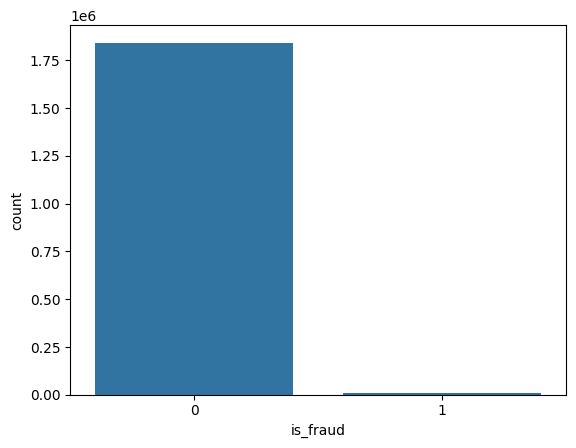

In [ ]:
#plots
sns.countplot(x='is_fraud', data=df_cards)
#how many records of fraud in the data set
df_cards['is_fraud'].value_counts()



([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'misc_net'),
  Text(1, 0, 'grocery_pos'),
  Text(2, 0, 'entertainment'),
  Text(3, 0, 'gas_transport'),
  Text(4, 0, 'misc_pos'),
  Text(5, 0, 'grocery_net'),
  Text(6, 0, 'shopping_net'),
  Text(7, 0, 'shopping_pos'),
  Text(8, 0, 'food_dining'),
  Text(9, 0, 'personal_care'),
  Text(10, 0, 'health_fitness'),
  Text(11, 0, 'travel'),
  Text(12, 0, 'kids_pets'),
  Text(13, 0, 'home')])

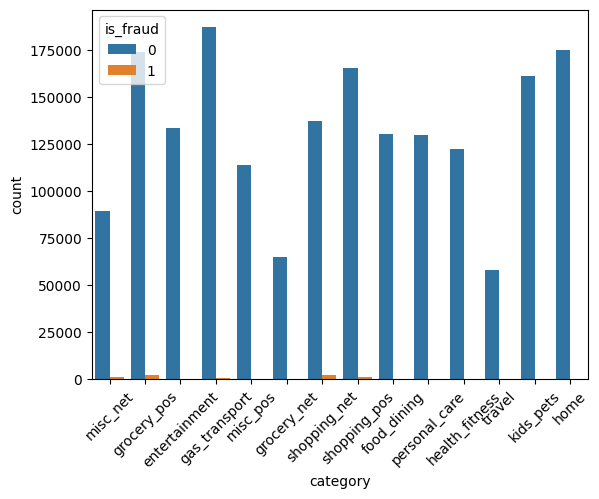

In [ ]:
#count plots
sns.countplot(x='category', hue='is_fraud', data=df_cards)
plt.xticks(rotation=45)


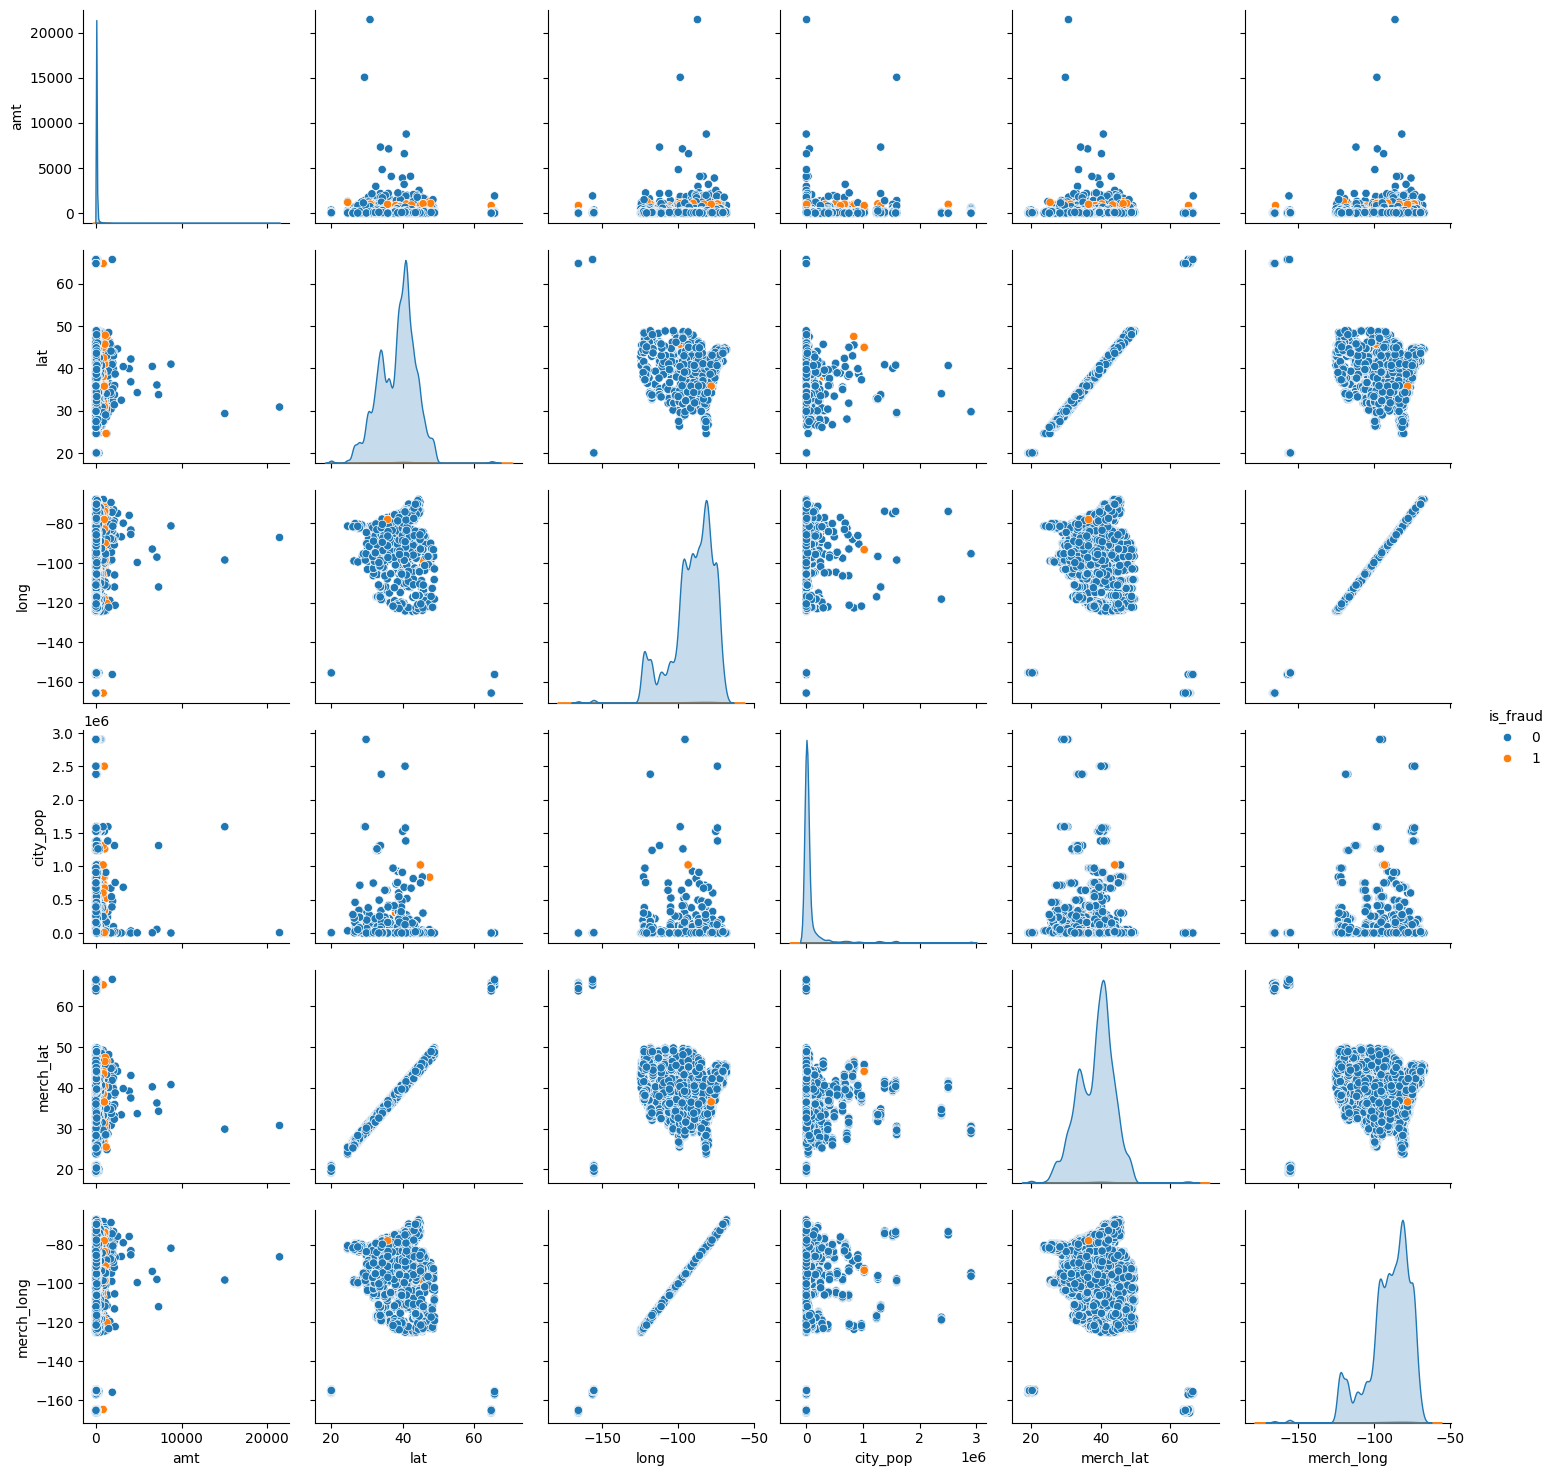

In [ ]:
#pair plots
columns_for_pairplot = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud']
df_sampled = df_cards[columns_for_pairplot].sample(n=50000, random_state=42)
sns.pairplot(df_sampled, hue='is_fraud', diag_kind='kde')